# NB05 — Backtest: Ablation of Three Strategies

**Three arms (one universe, same trading days):**

| Arm | Description |
|---|---|
| **BuyHold (EW50)** | Equal-weight passive hold of all 50 names; daily rebalance to 1/50 |
| **Tech-only** | Re-train arm B (tech features + sector) with NB04's best-model architecture/params; trade event-driven on its predictions |
| **Event-Study (LLM+Tech)** | NB04's tuned arm-C model (`event_study_best.pkl`); trade event-driven on its predictions |

**Event-driven trade:** at each earnings event, buy if `p > p_long_threshold`, sell-short if `p < p_short_threshold`. Hold from `event+2` for `LABEL_HOLDING_DAYS = 10` trading days. Equal-weight all open positions.

**Thresholds** are picked on **val 2023** as the cross-section quintile boundaries (top 20% long, bottom 20% short) of that arm's predicted probabilities, then frozen for test.

Compares Sharpe / annual return / MDD / IR vs SPY across arms.

In [1]:
import sys, warnings, joblib
from pathlib import Path
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path.cwd().parent))
sys.path.insert(0, str(Path.cwd().parent / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import config
from llm_agent.data_loader import load_sessions, load_prices, load_llm_signals, split_by_period
from llm_agent.features import build_feature_matrix, feature_columns
from llm_agent.models import predict_proba_safe
from llm_agent.metrics import compute_all_metrics

sns.set_style('whitegrid')
MAIN_WINDOW = 'car_2_11'
# Trade-execution params picked by val-2023 grid search (entry × hold × weighting)
ENTRY_OFFSET = 5      # open at event + 5 trading days (skip immediate reaction)
HOLDING_DAYS = 15     # hold 15 days (catch medium-term PEAD drift)
WEIGHTING    = 'prob' # 'equal' = ±1 fixed; 'prob' = 2*(p-0.5) capped to [-1, 1]


## 1. Load NB04 best model + base data

In [2]:
best = joblib.load(config.MODELS_DIR / 'event_study_best.pkl')
print(f'best model: {best["name"]}')
print(f'best params: {best["best_params"]}')

sessions = load_sessions()
prices = load_prices()
llm = load_llm_signals()
car = pd.read_parquet(config.CLEAN_DIR / 'car_labels.parquet')

# build daily price panel: date × ticker → adj_close return
px = prices.pivot_table(index='date', columns='ticker', values='adj_close').sort_index()
ret = px.pct_change()
trading_days = ret.index
print(f'panel: {ret.shape[0]} days × {ret.shape[1]} tickers')

best model: rf
best params: {'max_depth': 19, 'min_samples_leaf': 20, 'max_features': 0.8}
panel: 2150 days × 51 tickers


## 2. Build event-driven prediction frames for arms B (Tech) and C (LLM+Tech)

Arm C uses the saved tuned model directly (refit on train+val). Arm B refits the same architecture/params on the tech-only feature set.

In [3]:
def merged(arm):
    X = build_feature_matrix(sessions, prices, llm, arm)
    cols = feature_columns(arm)
    df = X.merge(car[['session_id', MAIN_WINDOW]], on='session_id', how='inner')
    return df.dropna(subset=cols + [MAIN_WINDOW]).sort_values('event_date').reset_index(drop=True), cols

df_C, cols_C = merged('C')
df_B, cols_B = merged('B')

# Arm C: use saved best model as-is
df_C['p'] = predict_proba_safe(best['model'], df_C[cols_C].values)

# Arm B: rebuild same architecture as the winner, refit on tech-only features (train+val)
def make_pipe(name):
    if name == 'logreg':
        return Pipeline([('scaler', StandardScaler()),
                         ('clf', LogisticRegression(max_iter=4000, solver='liblinear'))])
    if name == 'svm':
        return Pipeline([('scaler', StandardScaler()),
                         ('clf', SVC(probability=True))])
    if name == 'rf':
        return Pipeline([('scaler', StandardScaler()),
                         ('clf', RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1))])
    if name == 'xgb':
        return Pipeline([('scaler', StandardScaler()),
                         ('clf', XGBClassifier(n_estimators=500, eval_metric='logloss',
                                               random_state=0, n_jobs=-1, verbosity=0))])
    raise ValueError(name)

tech_pipe = make_pipe(best['name'])
# best_params from Optuna lacks the 'clf__' prefix that sklearn Pipelines need
_params = {(k if k.startswith('clf__') else f'clf__{k}'): v for k, v in best['best_params'].items()}
tech_pipe.set_params(**_params)

df_B['y'] = (df_B[MAIN_WINDOW] > 0).astype(int)
trval_B = pd.concat([split_by_period(df_B, 'train'), split_by_period(df_B, 'val')], ignore_index=True)
tech_pipe.fit(trval_B[cols_B].values, trval_B['y'].values)
df_B['p'] = predict_proba_safe(tech_pipe, df_B[cols_B].values)

print(f'arm B: {len(df_B)} sessions  | arm C: {len(df_C)} sessions')


arm B: 1480 sessions  | arm C: 1480 sessions


## 3. Pick long/short thresholds on val 2023

In [4]:
def quintile_thresholds(df, q=0.2):
    val = split_by_period(df, 'val')
    p = val['p']
    return float(p.quantile(1-q)), float(p.quantile(q))

thr_C = quintile_thresholds(df_C)
thr_B = quintile_thresholds(df_B)
print(f'arm C: long ≥ {thr_C[0]:.3f}, short ≤ {thr_C[1]:.3f}')
print(f'arm B: long ≥ {thr_B[0]:.3f}, short ≤ {thr_B[1]:.3f}')

arm C: long ≥ 0.573, short ≤ 0.420
arm B: long ≥ 0.599, short ≤ 0.437


## 4. Convert event predictions → daily portfolio returns

For each event passing the threshold, hold ±1 unit on the ticker for `[event+2, event+12)` (10 trading days). Each day the portfolio is equal-weighted across all currently-open positions; daily portfolio return = mean(daily returns × position sign) across open positions.

In [5]:
def daily_returns_from_events(df, ret_panel, thr, period_days,
                              hold=HOLDING_DAYS, entry=ENTRY_OFFSET, weighting=WEIGHTING):
    """Build a daily portfolio return series for one arm.

    Selection: p ≥ long_thr (long) or p ≤ short_thr (short); else skip.
    Weighting: 'equal' = ±1; 'prob' = 2·(p - 0.5) clipped to [-1, 1].
    Position runs over [event+entry, event+entry+hold). Daily PnL = mean(weight · daily ret) over open positions.
    """
    long_thr, short_thr = thr
    test_df = df[df['fiscal_year'].isin(period_days)].copy()
    p = test_df['p'].values
    if weighting == 'equal':
        w = np.where(p >= long_thr, 1.0, np.where(p <= short_thr, -1.0, 0.0))
    else:  # 'prob'
        raw = 2.0 * (p - 0.5)
        in_basket = (p >= long_thr) | (p <= short_thr)
        w = np.where(in_basket, np.clip(raw, -1.0, 1.0), 0.0)
    test_df = test_df.assign(weight=w).query('weight != 0')

    idx = ret_panel.index
    rets_per_day = {}
    for r in test_df.itertuples(index=False):
        if r.ticker not in ret_panel.columns:
            continue
        pos = idx.searchsorted(pd.Timestamp(r.event_date))
        lo, hi = pos + entry, pos + entry + hold
        if hi > len(idx):
            continue
        for i in range(lo, hi):
            r_d = ret_panel.iloc[i][r.ticker]
            if pd.isna(r_d):
                continue
            rets_per_day.setdefault(idx[i], []).append(r.weight * r_d)

    daily = pd.Series({d: np.mean(v) for d, v in rets_per_day.items()}).sort_index()
    return daily, len(test_df)

PERIODS = {
    'test_2024': config.TEST_YEARS_1,
    'test_2025': config.TEST_YEARS_2,
}

results_by_period = {}
for period_name, years in PERIODS.items():
    period_mask = ret.index.year.isin(years)
    bh = ret.loc[period_mask, [t for t in config.TICKERS if t in ret.columns]].mean(axis=1)
    spy = ret.loc[period_mask, 'SPY']

    tech_daily, n_tech = daily_returns_from_events(df_B, ret, thr_B, years)
    es_daily,   n_es   = daily_returns_from_events(df_C, ret, thr_C, years)

    period_index = ret.loc[period_mask].index
    tech_daily = tech_daily.reindex(period_index).fillna(0)
    es_daily   = es_daily.reindex(period_index).fillna(0)

    arms = {'BuyHold_EW50': bh, 'Tech': tech_daily, 'EventStudy': es_daily}
    metrics_rows = []
    for name, s in arms.items():
        m = compute_all_metrics(s, benchmark_returns=spy)
        metrics_rows.append({'arm': name, **m})
    metrics_df = pd.DataFrame(metrics_rows).set_index('arm').round(3)
    results_by_period[period_name] = (arms, metrics_df, spy, (n_tech, n_es))
    print(f'\n=== {period_name} (Tech traded {n_tech} events, EventStudy traded {n_es}) ===')
    print(f'  config: entry=+{ENTRY_OFFSET}, hold={HOLDING_DAYS}, weighting={WEIGHTING}')
    print(metrics_df[['sharpe','annual_return','volatility','max_drawdown','information_ratio']])


=== test_2024 (Tech traded 61 events, EventStudy traded 83) ===
  config: entry=+5, hold=15, weighting=prob
              sharpe  annual_return  volatility  max_drawdown  \
arm                                                             
BuyHold_EW50   2.067          0.237       0.106        -0.056   
Tech           0.304          0.011       0.040        -0.034   
EventStudy     0.429          0.016       0.038        -0.037   

              information_ratio  
arm                              
BuyHold_EW50             -0.242  
Tech                     -1.562  
EventStudy               -1.526  

=== test_2025 (Tech traded 60 events, EventStudy traded 71) ===
  config: entry=+5, hold=15, weighting=prob
              sharpe  annual_return  volatility  max_drawdown  \
arm                                                             
BuyHold_EW50   0.863          0.137       0.165        -0.171   
Tech          -0.126         -0.005       0.036        -0.034   
EventStudy     0.947      

## 5. Cumulative return curves

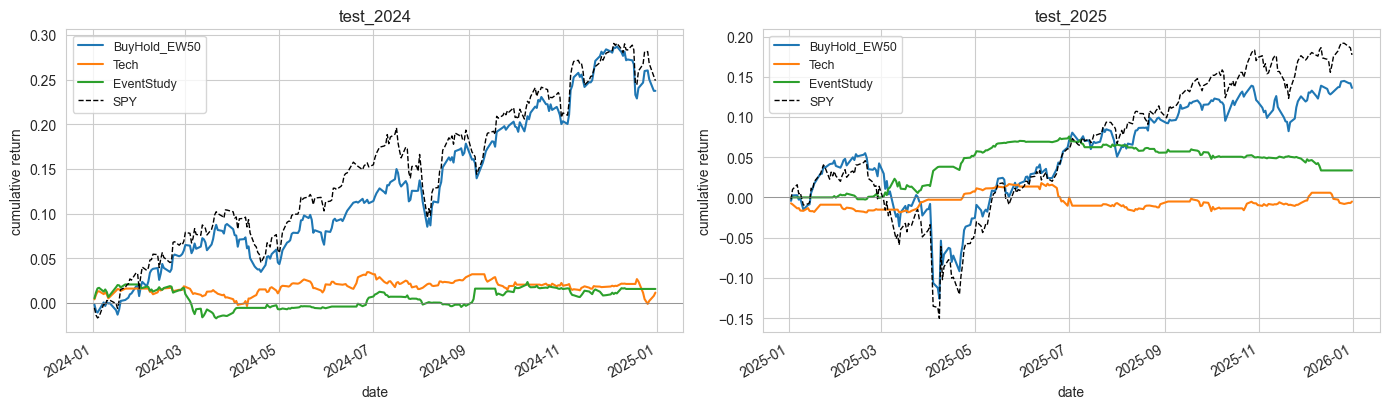

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), sharey=False)
for ax, period_name in zip(axes, PERIODS.keys()):
    arms, mdf, spy, _ = results_by_period[period_name]
    for name, s in arms.items():
        ((1+s).cumprod() - 1).plot(ax=ax, label=name, linewidth=1.5)
    ((1+spy).cumprod() - 1).plot(ax=ax, label='SPY', color='black', linestyle='--', linewidth=1.0)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_title(period_name)
    ax.set_ylabel('cumulative return')
    ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 6. Combined results table

In [7]:
combined = []
for period_name, (_, mdf, _, _) in results_by_period.items():
    for arm in mdf.index:
        row = {'period': period_name, 'arm': arm, **mdf.loc[arm].to_dict()}
        combined.append(row)
combined = pd.DataFrame(combined)
combined.to_parquet(config.SIGNALS_DIR / 'nb05_backtest.parquet')
print(combined.set_index(['period','arm'])[
    ['sharpe','annual_return','volatility','max_drawdown','information_ratio']
].round(3))
print('\nsaved', config.SIGNALS_DIR / 'nb05_backtest.parquet')

                        sharpe  annual_return  volatility  max_drawdown  \
period    arm                                                             
test_2024 BuyHold_EW50   2.067          0.237       0.106        -0.056   
          Tech           0.304          0.011       0.040        -0.034   
          EventStudy     0.429          0.016       0.038        -0.037   
test_2025 BuyHold_EW50   0.863          0.137       0.165        -0.171   
          Tech          -0.126         -0.005       0.036        -0.034   
          EventStudy     0.947          0.034       0.036        -0.039   

                        information_ratio  
period    arm                              
test_2024 BuyHold_EW50             -0.242  
          Tech                     -1.562  
          EventStudy               -1.526  
test_2025 BuyHold_EW50             -0.624  
          Tech                     -0.937  
          EventStudy               -0.722  

saved /Users/yishanranxin./Desktop/LLM_Active_

## 7. How to read the table

**Tech vs BuyHold** isolates whether *any* event-timing edge exists (price-only features).

**Event-Study vs Tech** isolates the **incremental contribution of LLM signals** — the headline question of the project. A Sharpe / IR gap here is the cleanest economic argument that the LLM extraction is doing real work beyond what β / sector / RSI already encode.

**Caveats:**
- Thresholds are frozen at val-set quintiles; turnover / position counts are not optimized.
- Trading costs default to 0; rerun with `cost_bps` parameterization in `metrics` if a slippage stress-test is needed.
- Holding window matches `LABEL_HOLDING_DAYS` (10) — overlapping positions are simply averaged equal-weight, no leverage cap.

---
## 8. Statistical significance

Four tests, applied per period:

1. **Newey–West t-stat** on each strategy's mean daily return vs 0 (lag=5 to absorb the 10-day overlapping holding period)
2. **Paired NW test on EventStudy − Tech daily PnL** — does the LLM signal add real alpha over Tech-only?
3. **Memmel (1996) Sharpe-difference z-test** — closed-form, with correlation correction
4. **Block bootstrap 95% CI on ΔSharpe** (5000 reps, block_len=10 to preserve holding-period dependence)


In [8]:
from scipy import stats
import statsmodels.api as sm

NW_LAG = 5
ANN = 252

def nw_tstat(x, lag=NW_LAG):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < 5:
        return np.nan, np.nan
    res = sm.OLS(x, np.ones(len(x))).fit(cov_type='HAC', cov_kwds={'maxlags': lag})
    t = float(res.tvalues[0])
    p = float(res.pvalues[0])
    return t, p

def memmel_z(r1, r2):
    """Memmel (1996) closed-form Sharpe-difference z-stat. Annualized Sharpes."""
    r1 = np.asarray(r1, dtype=float); r2 = np.asarray(r2, dtype=float)
    m = ~(np.isnan(r1) | np.isnan(r2))
    r1, r2 = r1[m], r2[m]
    n = len(r1)
    s1, s2 = r1.std(ddof=1), r2.std(ddof=1)
    sr1 = r1.mean()/s1 * np.sqrt(ANN)
    sr2 = r2.mean()/s2 * np.sqrt(ANN)
    rho = np.corrcoef(r1, r2)[0,1]
    # var of (Sharpe1 - Sharpe2), daily-Sharpe scale
    sr1d, sr2d = sr1/np.sqrt(ANN), sr2/np.sqrt(ANN)
    var = (1/n) * (2 - 2*rho + 0.5*(sr1d**2 + sr2d**2 - 2*rho**2*sr1d*sr2d))
    se = np.sqrt(var * ANN)
    z = (sr1 - sr2) / se
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return float(sr1 - sr2), float(z), float(p)

def block_bootstrap_sharpe_diff(r1, r2, block_len=10, n_boot=5000, seed=0):
    rng = np.random.default_rng(seed)
    r1 = np.asarray(r1, dtype=float); r2 = np.asarray(r2, dtype=float)
    m = ~(np.isnan(r1) | np.isnan(r2))
    r1, r2 = r1[m], r2[m]
    n = len(r1)
    n_blocks = int(np.ceil(n / block_len))
    diffs = np.empty(n_boot)
    for b in range(n_boot):
        starts = rng.integers(0, n - block_len + 1, size=n_blocks)
        idx = np.concatenate([np.arange(s, s+block_len) for s in starts])[:n]
        b1, b2 = r1[idx], r2[idx]
        sr1 = b1.mean()/b1.std(ddof=1) * np.sqrt(ANN) if b1.std() > 0 else 0
        sr2 = b2.mean()/b2.std(ddof=1) * np.sqrt(ANN) if b2.std() > 0 else 0
        diffs[b] = sr1 - sr2
    return float(np.percentile(diffs, 2.5)), float(np.percentile(diffs, 97.5))

print('Test 1+2: Newey-West t-stats (mean daily return ≠ 0, lag=5)\n')
sig_rows = []
for period_name, (arms, _, _, _) in results_by_period.items():
    for name, s in arms.items():
        t, p = nw_tstat(s.values)
        sig_rows.append({'period': period_name, 'arm': name,
                         'mean_daily_bps': float(s.mean()*1e4),
                         'NW_t': t, 'NW_p': p})
    # Paired diff: EventStudy - Tech
    diff = arms['EventStudy'].values - arms['Tech'].values
    t, p = nw_tstat(diff)
    sig_rows.append({'period': period_name, 'arm': 'EventStudy − Tech (paired)',
                     'mean_daily_bps': float(np.nanmean(diff)*1e4),
                     'NW_t': t, 'NW_p': p})
sig_df = pd.DataFrame(sig_rows).set_index(['period','arm']).round(3)
print(sig_df)


Test 1+2: Newey-West t-stats (mean daily return ≠ 0, lag=5)

                                      mean_daily_bps   NW_t   NW_p
period    arm                                                     
test_2024 BuyHold_EW50                         8.679  2.060  0.039
          Tech                                 0.483  0.303  0.762
          EventStudy                           0.640  0.394  0.694
          EventStudy − Tech (paired)           0.158  0.085  0.932
test_2025 BuyHold_EW50                         5.640  0.954  0.340
          Tech                                -0.180 -0.115  0.908
          EventStudy                           1.345  0.902  0.367
          EventStudy − Tech (paired)           1.525  0.760  0.448


In [9]:
print('Test 3+4: Sharpe-difference (EventStudy vs Tech)\n')
diff_rows = []
for period_name, (arms, _, _, _) in results_by_period.items():
    r_es, r_tech = arms['EventStudy'].values, arms['Tech'].values
    d_sr, z, p = memmel_z(r_es, r_tech)
    lo, hi = block_bootstrap_sharpe_diff(r_es, r_tech, block_len=10, n_boot=5000)
    diff_rows.append({
        'period': period_name,
        'ΔSharpe (ES-Tech)': d_sr,
        'Memmel_z': z, 'Memmel_p': p,
        'boot_CI_lo': lo, 'boot_CI_hi': hi,
        'CI_excludes_0': (lo > 0) or (hi < 0),
    })
diff_df = pd.DataFrame(diff_rows).set_index('period').round(3)
print(diff_df)


Test 3+4: Sharpe-difference (EventStudy vs Tech)

           ΔSharpe (ES-Tech)  Memmel_z  Memmel_p  boot_CI_lo  boot_CI_hi  \
period                                                                     
test_2024              0.125      0.11     0.913      -2.206       2.303   
test_2025              1.073      0.85     0.395      -2.196       3.184   

           CI_excludes_0  
period                    
test_2024          False  
test_2025          False  
